# Übung 9

**Gruppenname:**

*ESM*

Gehen Sie wie folgt vor:

1. Kopieren Sie jetzt dieses Jupyter Notebook in Ihren Ordner (`Abgaben/Team_WXYZ`)

2. Tragen Sie Ihren Gruppennamen auch ganz oben bei "Name Ihrer Gruppe" ein.

3. Bearbeiten Sie dann dieses Notebook. Falls Sie das Notebook im Browser bearbeiten, vergessen Sie nicht, es regelmäßig zu speichern (z.B. über `Strg + S` oder über `File -> Save and Checkpoint`).

### In dieser Übung ...

... werden Sie vertraut mit Clustervalidierungstechniken. Diese sind nützlich, um Parameter (wie beispielsweise die Anzahl der Cluster) einzustellen und die Qualität eines Clusterings zu bewerten.

### 9.1 Prediction Strength (Bestimmung der Clusteranzahl für $k$-Means)

Sie haben in der Vorlesung verschiedene Clustervalidierungsverfahren kennengelernt. Die *Prediction Strength* ist eine empfehlenswerte Validierungsmethode, die Sie im Rahmen dieser Übung implementieren und damit Ihr Verständnis vertiefen werden.

Hinweise

- Nutzen Sie die Implementierung des $k$-Means Algorithmus von scikit-learn.
- Für die Implementierung der *Prediction Strength* können Sie NumPy, sklearn und SciPy verwenden.

**Ihre Aufgaben**

(1) Bitte führen Sie die unten stehende Code-Zelle aus. Sie erzeugt 150 Datenpunkte mit je zwei Features (Merkmalen, Array **X**), organisiert in 5 Clustern. Die "wahren" Clusterzugehörigkeiten sind im Vektor **y** kodiert.

- In der Praxis haben Sie selbstverständlich keine wahren Clusterzugehörigkeiten vorliegen. Sie wollen vielmehr im Rahmen Ihrer Clusteranalyse diese Clusterzugehörigkeiten erkennen. In dieser Übung nutzen wir **y** lediglich für die Visualisierung, die die folgende Codezelle erzeugt, und löschen danach diese Variable wieder.

n_samples/m_features (150, 2)


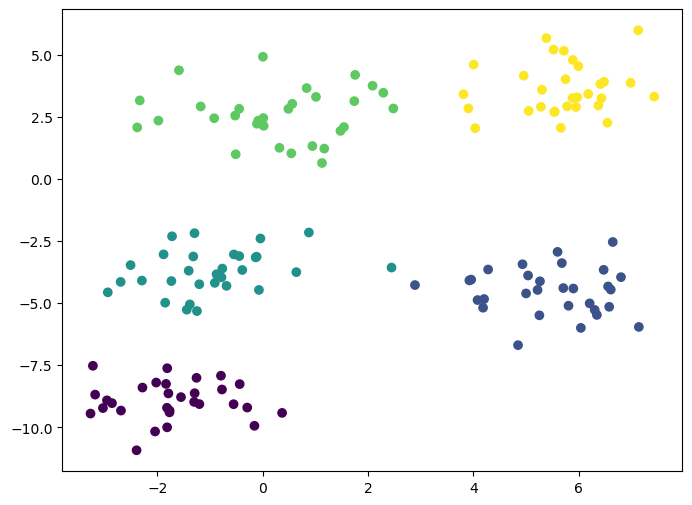

In [11]:
from sklearn.datasets import make_blobs
from matplotlib import pyplot as plt, rcParams
rcParams['figure.figsize'] = (8, 6)

# generate data
X, y = make_blobs(n_samples=150, centers=5, cluster_std=1, random_state=40)

# visualize data
plt.scatter(x=X[:, 0], y=X[:, 1], c=y)

del y

print(f"n_samples/m_features {X.shape}")

(2) [Teilen Sie](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) die Daten **zufällig** in Trainings- und Validierungsdaten auf. Die Validierungsdaten sollen dabei 20% der Gesamtdatenpunkte enthalten, die Trainingsdaten 80%.

- Ihre Datenvariablen heißen `X_train` und `X_valid`. (scikit-Learn bezeichnet unsere Validierungs- als Testdaten.)

- Nutzen Sie `random_state=40`, damit Sie Ihre Ergebnisse einfacher vergleichen können.

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_valid = train_test_split(X, random_state=40)

print(X_train.shape)
X_train

(112, 2)


array([[-4.48308789e-01,  2.83055279e+00],
       [ 6.20670366e+00, -5.00680511e+00],
       [-1.17833659e+00,  2.92630443e+00],
       [-1.88336286e+00, -3.03323460e+00],
       [-1.16951927e-01, -3.12663650e+00],
       [ 5.80498764e+00, -5.10233062e+00],
       [-5.54244423e-01, -9.06938977e+00],
       [-4.45478201e-02, -2.39391839e+00],
       [ 9.28907135e-03,  2.45869183e+00],
       [ 8.75268705e-01, -2.15240393e+00],
       [ 6.17976912e+00,  3.43055157e+00],
       [ 1.67853551e-02,  2.14609637e+00],
       [ 6.37215840e+00,  2.96373665e+00],
       [-1.81854779e+00, -9.21307877e+00],
       [ 6.57763844e+00, -5.14520694e+00],
       [ 3.81002751e+00,  3.42130879e+00],
       [-2.69880989e+00, -4.14212264e+00],
       [-4.38341635e-01, -8.25957093e+00],
       [ 5.25191657e+00, -5.48859954e+00],
       [ 5.88239374e+00,  3.26736938e+00],
       [-2.28444494e+00, -8.39923570e+00],
       [ 2.08429133e+00,  3.76032695e+00],
       [ 6.03952891e+00, -5.99527351e+00],
       [-4.

(3) Für die nachfolgenden (Debugging-)Schritte ist es hilfreich, wenn Sie bereits jetzt mittels $k$-Means jeweils Cluster in Trainings- und Validierungsdaten bestimmen.

- Nutzen Sie bei den nachfolgenden Schritten jeweils `random_state=40`, um vergleichbare Ergebnisse zu erhalten.

1. Ermitteln Sie mit [$k$-Means](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) $k=8$ Cluster in den **Trainingsdaten** (setzen Sie den Parameter `n_init=10`, um die Warnung zu deaktivieren). Speichern Sie die Zentren der Cluster (auch *centroids* genannt) in der Variablen `train_centroids`.
2. Ermitteln Sie mit einem **neuen** k-Means Modells ebenfalls $k=8$ Cluster in den **Validierungsdaten** (setzen Sie den Parameter `n_init=10`, um die Warnung zu deaktivieren). Speichern Sie die Clusterzugehörigkeiten (*cluster labels*) der Validierungsdaten in der Variablen `valid_labels`.

In [17]:
from sklearn.cluster import KMeans
import numpy as np

# a)
kmeans = KMeans(n_clusters=8, random_state=40, n_init=10).fit(X_train)
train_labels = np.copy(kmeans.labels_)
train_centroids = np.copy(kmeans.cluster_centers_)

print(train_centroids.shape)

# b)
kmeans.fit(X_valid)
test_labels = np.copy(kmeans.labels_)
test_centroids = np.copy(kmeans.cluster_centers_)
print(test_centroids.shape)


(8, 2)
(8, 2)


(4) Sie werden die Prediction Strength in mehreren Schritten implementieren. Implementieren Sie zunächst eine Funktion `get_comembership_matrix`, die die Co-Membership Matrix $M$ (Ko-Mitgliedschaftsmatrix) aus den Daten bestimmt.

**Hintergrund**

Die Matrix $M$ kodiert, welches Paar von Datenpunkten aus den Validierungsdaten demselben Cluster der Trainingsdaten zugeordnet ist. 


*Damit enthält die Implementierung der Funktion `get_comembership_matrix` implizit unsere Annahmen darüber, wie ein Clustergebiet aussehen sollte.* Verschiedene Clusterverfahren treffen unterschiedliche Annahmen. Daher unterscheidet sich die Implementierung von `get_comembership_matrix` je nach gewähltem Clusteringverfahren!

Wir wollen später Clusterings validieren, die wir mittels $k$-Means erzeugt haben. Bei $k$-Means werden Datenpunkte dem Cluster zugeordnet, dessen Clusterzentrum sie am nächsten liegen. Um zu bestimmen, ob zwei Datenpunkte aus den Validierungsdaten demselben Cluster der Trainingsdaten angehören, müssen Sie also prüfen, ob Sie demselben Clusterzentrum der Trainingsdaten am nächsten liegen.

**Hinweise**

- Die Funktion `get_comembership_matrix` nimmt die Daten `X_valid` sowie die `train_centroids` entgegen und gibt die Co-Membership Matrix `M` zurück.

- Bei der Implementierung können Funktionen hilfreich sein, die Sie bei (i) der Bestimmung [euklidischer Distanzen](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.cdist.html), (ii) bei der Bestimmung des [Arrayindexes mit dem kleinsten Eintrag](https://numpy.org/doc/stable/reference/generated/numpy.argmin.html) sowie (iii) der [Bestimmung aller Indizes von Arrayeinträgen](https://numpy.org/doc/stable/reference/generated/numpy.argwhere.html), die eine Bedingung erfüllen, unterstützen.


In [23]:
def get_min_dist_idx(x, centroids):
    return np.argmin([np.linalg.norm(x - c) for c in centroids])


def get_comembership_matrix(X_valid, train_centroids):
    n_samples, m_features = X_valid.shape
    return np.array([[1 if 
                      get_min_dist_idx(X_valid[i], train_centroids) == get_min_dist_idx(X_valid[j], train_centroids)
                      else 0 
                      for j in range(n_samples)
                      ] 
                      for i in range(n_samples)])

M = get_comembership_matrix(X_valid, train_centroids)
M 



array([[1, 1, 0, ..., 0, 0, 0],
       [1, 1, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 1],
       ...,
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 1, 0],
       [0, 0, 1, ..., 0, 0, 1]], shape=(38, 38))

(5) Implementieren Sie nun die Funktion `get_prediction_strength`, die eine Co-Membership Matrix `M`, die Clusterzugehörigkeiten auf den Validierungsdaten `valid_labels` sowie die Anzahl $k$ von Clustern entgegennimmt und die *Prediction Strength* `ps` zurückliefert.

- Bei der Implementierung kann [dies hier](https://numpy.org/doc/stable/reference/generated/numpy.argwhere.html) hilfreich sein.

In [ ]:
def get_prediction_strength(M, validate_labels, k):

    ps = np.zeros(k)

    for l in range(k):
        member_idxs = np.where(validate_labels == l)[0]
        size = len(member_idxs)

        if size < 2: 
            ps[l] = np.nan
        else:
           sub_m = M[np.ix_(member_idxs, member_idxs)]
           pair_sum = np.sum(sub_m) - np.trace(sub_m)
           ps[l] = pair_sum / (size * (size - 1)) 

    return np.nanmin(ps)

ps = get_prediction_strength(M, test_labels, 8)

np.float64(0.3333333333333333)

(6) Visualisieren Sie die *Prediction Strength* als Funktion der Clusteranzahl $K$ für $K\in\{1, \ldots 9\}$.

Hierzu müssen Sie für jeden Wert $K$ ein Clustering auf den Trainingsdaten und auf den Validierungsdaten durchführen, die Co-Membership-Matrix $M$ und anschließend die Prediction Strength bestimmen. Beschriften Sie die y-Achse mit "Prediction Strength" und die x-Achse mit "Clusteranzahl".

Text(0.5, 1.0, 'Prediction Strenght of KMeans')

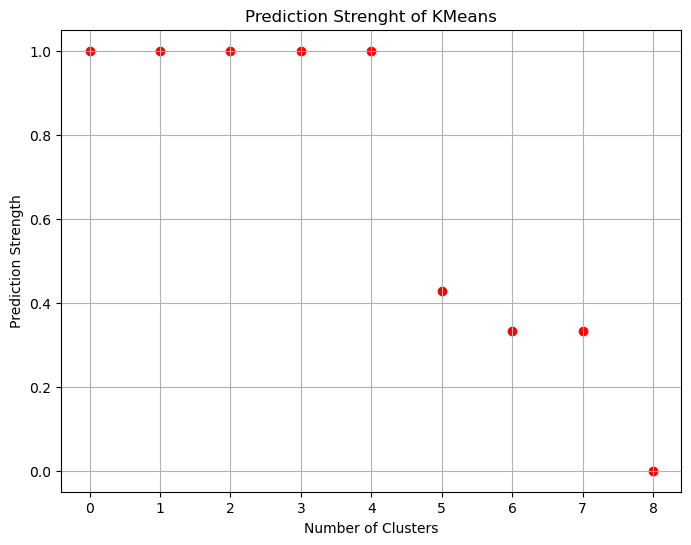

In [46]:
import matplotlib.pyplot as plt

def validate_clusters(k=8):

    ps = np.zeros(k)    

    for i in range(1,k):

        kmeans = KMeans(n_clusters=i, random_state=40, n_init=10).fit(X_train)
        train_labels = np.copy(kmeans.labels_)
        train_centroids = np.copy(kmeans.cluster_centers_)

        kmeans.fit(X_valid)
        test_labels = np.copy(kmeans.labels_)
        test_centroids = np.copy(kmeans.cluster_centers_)

        M = get_comembership_matrix(X_valid, train_centroids)
        ps[i  - 1] = get_prediction_strength(M, test_labels, k)

    return ps

k = 9
ps = validate_clusters(k)

plt.scatter(np.arange(k), ps, c="red")
plt.grid(True)
plt.xlabel("Number of Clusters")
plt.ylabel("Prediction Strength")
plt.title("Prediction Strenght of KMeans")



(7) Lesen Sie die optimale Anzahl an Clustern anhand Ihrer Visualisierung aus Schritt (7) ab und geben Sie sie hier an. Die optimale Clusteranzahl ist die größte Zahl $K>1$, für die die Prediction Strength noch den größten Wert annimmt.

Maximal 4 Clusters

- Stimmt die von Ihnen ermittelte Clusteranzahl mit der "wahren" Anzahl der Cluster (vgl. Schritt (1)) in den Daten überein?

Nein

(8) \[Optional\] In der Praxis wird oft die Prediction Strength im Rahmen einer sogenannten Cross Validation ("Kreuzvalidierung") ermittelt. Dabei werden alle Daten `X` in $V$ disjunkte Mengen (sogenannte Blöcke bzw. *Folds*) aufgespalten, wobei die Daten aus $(V-1)$ Blöcken als Trainingsdaten und dem verbliebenen Block als Validierungsdaten angesehen werden. Durch Durchtauschen der Zuordnungen der Blöcke zu Trainings- und Validierungsdaten lässt sich so $V$ mal die Prediction Strength bestimmen (jeder Block dient einmal als Validierungsdatensatz). Die $V$ Werte für die Prediction Strength werden anschließend arithmetisch gemittelt.

- Bestimmen Sie für $k\in\{1, \ldots, 9\}$ mittels 5-facher Kreuzvalidierung die Prediction Strength und visualisieren Sie sie. Dabei kann Ihnen ggf. [diese Funktion](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html) helfen.
- In der Regel wird die Anzahl der Blöcke mit $k$ bezeichnet. Um Verwechselungen mit der Anzahl der Cluster $k$ zu vermeiden, bezeichnet hier $V$ die Anzahl der Blöcke.
